## Demographic characterization

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")

In [2]:
def freq_table(series: pd.Series, label: str, order=None) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).fillna(0).astype(int)
    pct = (counts / counts.sum() * 100).round(1)
    out = pd.DataFrame({"Category": counts.index, "n": counts.values, "%": pct.values})
    out.insert(0, "Variable", "")
    out.iloc[0, 0] = label
    return out

blocks = [
    freq_table(df["gender_norm"], "Gender"),
    freq_table(df["age_band"], "Age band",
               order=["18-24 years", "25-34 years", "35-44 years", "45-54 years", "55-64 years"]),
    freq_table(df["norm_country"], "Country"),
    freq_table(df["education_norm"], "Education"),
    freq_table(df["role_group"], "Role"),
    freq_table(df["seniority_norm"], "Seniority"),
]
demo_table = pd.concat(blocks, ignore_index=True)
demo_table = demo_table[demo_table["n"] > 0].reset_index(drop=True)
demo_table

,Variable,Category,n,%
0,Gender,male,45,80.4
1,,female,11,19.6
2,Country,Brazil,42,75.0
3,,United States,5,8.9
4,,Germany,4,7.1
5,,France,2,3.6
6,,Ireland,1,1.8
7,,Colombia,1,1.8
8,,China,1,1.8
9,Education,Doctoral student,18,32.1


In [4]:
df["n_projects"].value_counts()

n_projects
3     10
2      9
5      6
6      5
4      5
1      4
10     3
8      3
0      2
40     2
15     2
7      2
13     1
11     1
25     1
Name: count, dtype: int64

## Q8 — Self-assessed skill level in data processing activities

In [5]:
def _bootstrap_ci(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    items: list,
    top_levels: list[int],
    bottom_levels: list[int],
    n_bootstrap: int = 1000,
    ci_level: float = 0.95,
    random_state: int | None = 42,
) -> pd.DataFrame:

    rng = np.random.default_rng(random_state)
    alpha = 1 - ci_level
    rows = {}

    for key in items:
        s = long_df.loc[long_df[item_col] == key, value_col].dropna()
        n = len(s)

        if n == 0:
            rows[key] = {
                "pct_top2": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan"),
                "pct_bottom2": float("nan"), "ci_bottom_lo": float("nan"), "ci_bottom_hi": float("nan")
            }
            continue

        vals = s.values
        pct_top2    = s.isin(top_levels).mean()    * 100
        pct_bottom2 = s.isin(bottom_levels).mean() * 100

        boot_indices = rng.integers(0, n, size=(n_bootstrap, n))
        boot_props_top    = np.isin(vals[boot_indices], top_levels).mean(axis=1)    * 100
        boot_props_bottom = np.isin(vals[boot_indices], bottom_levels).mean(axis=1) * 100

        rows[key] = {
            "pct_top2":     pct_top2,
            "ci_lo":        np.percentile(boot_props_top,    100 * alpha / 2),
            "ci_hi":        np.percentile(boot_props_top,    100 * (1 - alpha / 2)),
            "pct_bottom2":  pct_bottom2,
            "ci_bottom_lo": np.percentile(boot_props_bottom, 100 * alpha / 2),
            "ci_bottom_hi": np.percentile(boot_props_bottom, 100 * (1 - alpha / 2)),
        }

    return pd.DataFrame(rows).T


# Neutral uses #D9D9D9 (visible mid-gray); U.PALETTE_LIKERT_5[2] is near-white (#f7f7f7)
_PALETTE_LIKERT_5 = ["#3B1F6E", "#9B72CF", "#D9D9D9", "#7BC67E", "#1A6B3C"]


def diverging_stacked(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    item_labels: dict[str, str],
    level_labels: list[str],
    figsize: tuple[float, float] = (7.0, 4.5),
    palette: list[str] | None = None,
    sort_by_positive: bool = True,
    ci_df: pd.DataFrame | None = None,
) -> plt.Figure:

    n_levels = len(level_labels)
    if palette is None:
        palette = _PALETTE_LIKERT_5 if n_levels == 5 else [f"C{i}" for i in range(n_levels)]

    items = list(item_labels.keys())

    counts = (
        long_df.groupby(item_col)[value_col]
        .value_counts().unstack(fill_value=0)
        .reindex(index=items, columns=range(1, n_levels + 1), fill_value=0)
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    if sort_by_positive:
        positive = pct[[n_levels - 1, n_levels]] if n_levels >= 4 else pct[[n_levels]]
        order    = positive.sum(axis=1).sort_values().index
        pct      = pct.loc[order]
        counts   = counts.loc[order]
        items    = list(order)

    if n_levels == 5:
        neg_levels, neutral, pos_levels = [1, 2], 3, [4, 5]
    elif n_levels == 4:
        neg_levels, neutral, pos_levels = [1, 2], None, [3, 4]
    else:
        raise ValueError("diverging_stacked expects 4 or 5 levels")

    fig, ax = plt.subplots(figsize=figsize)
    y          = np.arange(len(items))
    bar_height = 0.76

    neutral_half = (pct[neutral].values / 2) if neutral is not None else np.zeros(len(items))
    cur = -(neutral_half + pct[neg_levels[1]].values + pct[neg_levels[0]].values)

    # negative bars
    for lvl, color in zip(neg_levels, palette[:len(neg_levels)]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, height=bar_height,
                color=color, edgecolor="white", linewidth=0.4,
                label=level_labels[lvl - 1])
        for i, w in enumerate(widths):
            if w >= 4:
                ax.text(cur[i] + w / 2, y[i], f"{w:.0f}%",
                        ha="center", va="center", fontsize=9,
                        color="white", fontweight="bold")
        cur += widths

    # neutral bar
    if neutral is not None:
        widths = pct[neutral].values
        ax.barh(y, widths, left=-widths / 2, height=bar_height,
                color=palette[neutral - 1], edgecolor="white", linewidth=0.4,
                label=level_labels[neutral - 1])
        for i, w in enumerate(widths):
            if w >= 4:
                ax.text(-widths[i] / 2 + w / 2, y[i], f"{w:.0f}%",
                        ha="center", va="center", fontsize=9, color="#333333")

    # positive bars
    cur = neutral_half.copy()
    for lvl, color in zip(pos_levels, palette[-len(pos_levels):]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, height=bar_height,
                color=color, edgecolor="white", linewidth=0.4,
                label=level_labels[lvl - 1])
        for i, w in enumerate(widths):
            if w >= 4:
                ax.text(cur[i] + w / 2, y[i], f"{w:.0f}%",
                        ha="center", va="center", fontsize=9,
                        color="white", fontweight="bold")
        cur += widths

    # CI shadow band
    if ci_df is not None:
        ci_al  = ci_df.reindex(items)
        band_h = bar_height * 0.55
        if "pct_top2" in ci_al.columns:
            x_lo = neutral_half + ci_al["ci_lo"].values
            x_hi = neutral_half + ci_al["ci_hi"].values
            ax.barh(y, x_hi - x_lo, left=x_lo, height=band_h,
                    color="#888888", alpha=0.30, zorder=5, label="95% CI")
        if "pct_bottom2" in ci_al.columns:
            x_lo = -(neutral_half + ci_al["ci_bottom_hi"].values)
            x_hi = -(neutral_half + ci_al["ci_bottom_lo"].values)
            ax.barh(y, x_hi - x_lo, left=x_lo, height=band_h,
                    color="#888888", alpha=0.30, zorder=5)

    ax.axvline(0, color="#333333", linewidth=0.7, zorder=4, linestyle="--", alpha=0.4)

    ax.set_yticks(y)
    ax.set_yticklabels([item_labels[k] for k in items], fontsize=10.5)
    ax.set_xlabel("% of responses", fontsize=10.5)

    ax.set_xlim(-75, 100)
    ax.set_xticks([-75, -50, -25, 0, 25, 50, 75, 100])
    ax.set_xticklabels(["75%", "50%", "25%", "0", "25%", "50%", "75%", "100%"], fontsize=9.5)
    ax.tick_params(axis="x", length=3)

    ax.grid(axis="x", color="#e0e0e0", linewidth=0.5, zorder=0)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")

    handles, labels_leg = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels_leg):
        if l not in seen:
            seen[l] = h
    ax.legend(list(seen.values()), list(seen.keys()),
              loc="upper center", bbox_to_anchor=(0.5, -0.13),
              ncol=len(seen), frameon=False, fontsize=9.5,
              handlelength=1.3, handleheight=0.85,
              borderpad=0, columnspacing=0.9)

    return fig

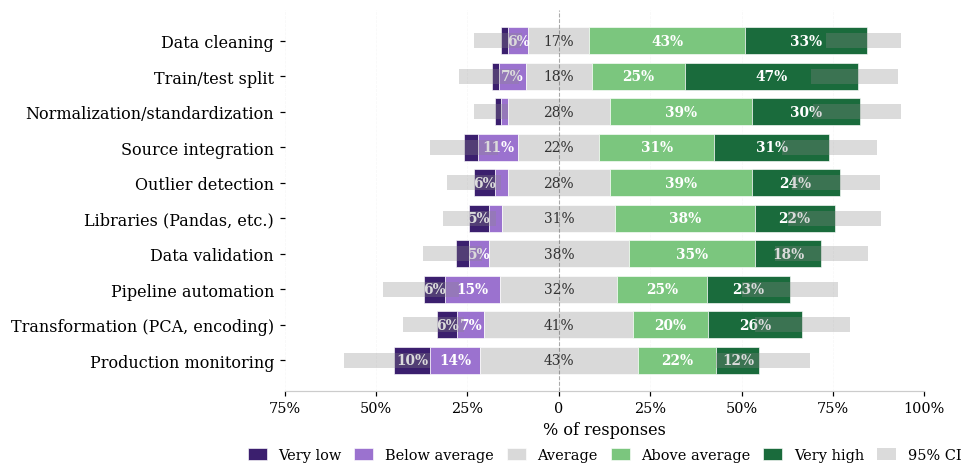

In [6]:
skills_renamed = skills_long.copy()
_skill_items = list(U.SKILL_LABELS_EN.keys())

_skill_ci = _bootstrap_ci(
    skills_renamed.dropna(),
    "activity",
    "skill",
    _skill_items,
    top_levels=[4, 5],
    bottom_levels=[1, 2],
)

fig = diverging_stacked(
    skills_renamed.dropna(),
    item_col="activity",
    value_col="skill",
    item_labels=U.SKILL_LABELS_EN,
    level_labels=["Very low", "Below average", "Average", "Above average", "Very high"],
    figsize=(7.5, 4.5),
    ci_df=_skill_ci,
)

U.save_fig(fig, "skills_diverging")
plt.show()
